In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.offsetbox import OffsetImage, AnnotationBbox
from pyvis.network import Network
import networkx as nx
import os
from PIL import Image
from textwrap import fill
import statistics
from IPython.display import clear_output
from collections import defaultdict
import json
import random

__Loading Data__

Helper Functions for loading data

In [2]:
# Read the JSON file
def read_anime_recommendations(file_path):
    with open(file_path, 'r') as file:
        data = json.load(file)
    return data

# Extract anime information in a more usable format
def extract_anime_info(data):
    all_anime = []
    
    # Iterate through each key-value pair in the dictionary
    for anime_id, recommendations in data.items():
        # Iterate through each recommendation in the list
        for rec in recommendations:
            anime_info = {
                'source_id': anime_id,  # The key in the outer dictionary
                'anime_id': rec['node']['id'],
                'title': rec['node']['title'],
                'image_medium': rec['node']['main_picture']['medium'],
                'image_large': rec['node']['main_picture']['large'],
                'num_recommendations': rec['num_recommendations']
            }
            all_anime.append(anime_info)
    
    return all_anime

# Convert to DataFrame if needed
def convert_to_dataframe(anime_list):
    import pandas as pd
    return pd.DataFrame(anime_list)

Data Files

In [3]:
anime = pd.read_csv('backupdata/anime_data.csv')
anime_recs = read_anime_recommendations('anime_recommendations_full.json')

In [4]:
anime.head(2)

,id,title,main_picture,alternative_titles,start_date,end_date,synopsis,mean,rank,popularity,num_list_users,num_scoring_users,genres,media_type,status,num_episodes
0,52991,Sousou no Frieren,"{""medium"": ""https://cdn.myanimelist.net/images...","{""synonyms"": [""Frieren at the Funeral"", ""Frier...",2023-09-29,2024-03-22,During their decade-long quest to defeat the D...,9.31,1,156,1065722,624327,"[{""id"": 2, ""name"": ""Adventure""}, {""id"": 8, ""na...",tv,finished_airing,28
1,5114,Fullmetal Alchemist: Brotherhood,"{""medium"": ""https://cdn.myanimelist.net/images...","{""synonyms"": [""Hagane no Renkinjutsushi: Fullm...",2009-04-05,2010-07-04,After a horrific alchemy experiment goes wrong...,9.10,2,3,3497034,2204122,"[{""id"": 1, ""name"": ""Action""}, {""id"": 2, ""name""...",tv,finished_airing,64


__Setup__ - Helper Functions

In [5]:
def get_unique_id_name_pairs(data):
    unique_pairs = set()

    for collection in data:
        if type(collection) == str:
            for item in json.loads(collection):
                unique_pairs.add((item['id'], item['name']))

    return list(unique_pairs) 

def count_id_name_pairs(data):
    pair_counts = defaultdict(int)

    for collection in data:
        if type(collection) == str:
            for item in json.loads(collection):
                id_val = item['id']
                name_val = item['name']

                pair_counts[name_val] += 1
    
    return pair_counts

# loop through dataframe and get id, genres pairs and make into dictionary
def get_id_genre_dict(data):
    id_genre_dict = defaultdict(list)

    for index, row in data.iterrows():
        if type(row['genres']) == str:
            genres = json.loads(row['genres'])
            for genre in genres:
                id_genre_dict[row['id']].append(genre['name'])

    return id_genre_dict

In [6]:
'''
Create directed graph from anime recommendation data.

Params:
data(dict): Dictionary where keys are anime IDs and values are lists of recommendations

Returns:
G (nx.DiGraph): A directed graph where nodes are anime IDs and edges represent recommendations
'''
def create_anime_rec_network(data):
    G = nx.DiGraph()

    for source_id, recommendations in data.items():
        source_id = int(source_id)
        G.add_node(source_id)
        for rec in recommendations:
            target_id = rec['node']['id']
            G.add_node(target_id)
            G.add_edge(source_id, target_id)
    
    return G

# create a weighted network
def create_weighted_anime_rec_network(data):
    G = nx.DiGraph()

    for source_id, recommendations in data.items():
        source_id = int(source_id)
        G.add_node(source_id)
        for rec in recommendations:
            target_id = rec['node']['id']
            G.add_node(target_id)
            weight = rec['num_recommendations']
            G.add_edge(source_id, target_id, weight=weight)
    
    return G

In [7]:
def visualize_basic_network(G, limit=20):
    """
    Create a simple visualization of the anime network.
    
    Parameters:
    G (nx.DiGraph): The anime recommendation network
    limit (int): Maximum number of nodes to show
    """
    # Take a subset of nodes if the graph is too large
    if len(G) > limit:
        # Get the most connected nodes
        degrees = dict(G.degree())
        top_nodes = sorted(degrees.items(), key=lambda x: x[1], reverse=True)[:limit]
        nodes_to_show = [node for node, _ in top_nodes]
        G_sub = G.subgraph(nodes_to_show)
    else:
        G_sub = G
    
    # Create the visualization
    plt.figure(figsize=(10, 8))
    
    # Use a simple layout
    pos = nx.spring_layout(G_sub, seed=42)
    
    # Draw the nodes and edges
    nx.draw_networkx_nodes(G_sub, pos, node_size=300, node_color='lightblue')
    nx.draw_networkx_edges(G_sub, pos, arrows=True)
    
    # Add labels
    labels = {node: str(node) for node in G_sub.nodes()}
    nx.draw_networkx_labels(G_sub, pos, labels=labels, font_size=10)
    
    plt.title("Anime Recommendation Network (Basic)")
    plt.axis('off')
    plt.tight_layout()
    plt.show()

In [8]:
def visualize_connected_components(G, max_components=5, min_size=5, max_size = 10):
    """
    Visualize a few largest connected components of the graph.

    Parameters:
    -----------
    G : networkx.Graph or DiGraph
        The anime recommendation graph.
    max_components : int
        Maximum number of components to plot.
    min_size : int
        Minimum size of component to consider (to avoid tiny ones).
    """
    # Find weakly connected components (good for DiGraph)
    components = list(nx.weakly_connected_components(G))
    
    # Filter components by size
    large_components = [c for c in components if len(c) >= min_size and len(c) <= max_size]

    if not large_components:
        print("No components large enough to display.")
        return

    # Sort components by size (largest first)
    large_components.sort(key=len, reverse=True)

    # Limit to max_components
    selected_components = large_components[:max_components]

    # Create a combined subgraph
    selected_nodes = set().union(*selected_components)
    subG = G.subgraph(selected_nodes)

    # Create a layout for visualization
    pos = nx.spring_layout(subG, seed=42)  # seed for consistent layout

    # Color each component differently
    component_colors = {}
    colors = plt.cm.tab20.colors  # 20 different colors to cycle through

    for idx, comp in enumerate(selected_components):
        for node in comp:
            component_colors[node] = colors[idx % len(colors)]

    node_colors = [component_colors[n] for n in subG.nodes]

    # Plot
    plt.figure(figsize=(12, 10))
    nx.draw(subG, pos,
            node_color=node_colors,
            edge_color='gray',
            with_labels=False,
            node_size=50,
            alpha=0.8)
    
    plt.title(f"Visualization of {len(selected_components)} Connected Components", fontsize=15)
    plt.axis('off')
    plt.show()

In [9]:
def visualize_cc_images(G, image_folder="images_cropped", 
                        max_components=5, min_size=5, max_size=10,
                        zoom=0.2, output_file=None, show_labels=True):
    """
    Visualize a few largest connected components with node images, adjusting for overlap.
    """
    components = list(nx.weakly_connected_components(G))
    large_components = [c for c in components if min_size <= len(c) <= max_size]

    if not large_components:
        print("No components large enough to display.")
        return

    large_components.sort(key=len, reverse=True)
    selected_components = large_components[:max_components]
    selected_nodes = set().union(*selected_components)
    subG = G.subgraph(selected_nodes)

    # Layout: Adjust k to separate nodes
    pos = nx.spring_layout(subG, seed=42, k=1.5, iterations=100)
    # pos = nx.kamada_kawai_layout(subG)
    # Can vary level of separation using k=0.5 or k=1.0 (default is k=None which is 1/sqrt(n))
    # Larger k --> more spread out

    plt.figure(figsize=(14, 12))

    colors = plt.cm.tab20.colors # 20 different colors to cycle through
    for idx, comp in enumerate(selected_components):
        color = colors[idx % len(colors)]  # cycle through color map
        comp_nodes = list(comp)
        comp_edges = [(u, v) for u, v in subG.edges if u in comp_nodes and v in comp_nodes]

        for u, v in comp_edges:
            # Dynamically calculate margin if you want (same as before)
            target_id = v
            image_path = os.path.join(image_folder, f"{target_id}.png")

            if os.path.exists(image_path):
                try:
                    img = Image.open(image_path)
                    width, height = img.size
                    img_min_dim = min(width, height)
                    local_margin = zoom * img_min_dim * 0.6
                except Exception as e:
                    print(f"Image read error {target_id}: {e}")
                    local_margin = 10
            else:
                local_margin = 10

            # Draw this edge with the component color
            nx.draw_networkx_edges(
                subG, pos,
                edgelist=[(u, v)],
                arrows=True,
                arrowstyle='-|>',
                connectionstyle='arc3,rad=0.1',
                edge_color=[color],   # key: use the assigned color
                arrowsize=18,
                min_target_margin=local_margin
            )


    ax = plt.gca()

    for node in subG.nodes:
        x, y = pos[node]
        anime_id = node
        image_path = os.path.join(image_folder, f"{anime_id}.png")
        title = get_anime_title(anime_id)  # Assuming you have this function
        
        if os.path.exists(image_path):
            try:
                img = Image.open(image_path)
                im = OffsetImage(img, zoom=zoom)
                ab = AnnotationBbox(im, (x, y), frameon=False)
                ax.add_artist(ab)

                if show_labels:
                    ax.text(
                        x,
                        y - (0.03 * zoom),
                        title,
                        ha='center',
                        va='top',
                        fontsize=6,
                        color='white',
                        bbox=dict(facecolor='black', alpha=0.5, boxstyle='round,pad=0.2')
                    )

            except Exception as e:
                print(f"Error loading image for node {anime_id}: {e}")
                ax.plot(x, y, 'o', color='blue', markersize=5)
        else:
            ax.plot(x, y, 'o', color='blue', markersize=5)

    plt.title(f"Visualization of {len(selected_components)} Connected Components", fontsize=18)
    plt.axis('off')

    if output_file:
        plt.savefig(output_file, dpi=300, bbox_inches='tight')
        print(f"Saved visualization to {output_file}")
    plt.show()

In [10]:
def draw_star_network(animeGraph, center_anime_id, anime_df, title=None):
    """
    Draw a star-style network: center anime with incoming links from its recommenders.

    Parameters:
    -----------
    animeGraph : networkx.DiGraph
    center_anime_id : int
        ID of the anime to center (most connected anime).
    anime_df : pandas DataFrame
        DataFrame containing anime data.
    title : str or None
        Optional custom title for the plot.
    """
    # Find predecessors (incoming edges)
    incoming = list(animeGraph.predecessors(center_anime_id))

    if not incoming:
        print("No incoming recommendations for this anime.")
        return

    # Build subgraph
    nodes = incoming + [center_anime_id]
    subG = animeGraph.subgraph(nodes)

    # Layout: Center anime at (0,0), others around in a circle
    pos = {}

    # Place center
    pos[center_anime_id] = (0, 0)

    # Place recommenders around in a circle
    num_incoming = len(incoming)
    radius = 1.0  # control how far recommenders are placed
    for i, node in enumerate(incoming):
        angle = 2 * 3.14159 * i / num_incoming
        x = radius * np.cos(angle)
        y = radius * np.sin(angle)
        pos[node] = (x, y)

    plt.figure(figsize=(10,10))

    # Node sizes
    node_sizes = [800 if node == center_anime_id else 300 for node in subG.nodes()]
    node_colors = ['red' if node == center_anime_id else 'lightblue' for node in subG.nodes()]

    # Draw
    nx.draw(
        subG, pos,
        with_labels=False,
        node_size=node_sizes,
        node_color=node_colors,
        edge_color='gray',
        arrows=True,
        arrowstyle='-|>',
        arrowsize=15
    )

    # Add labels
    for node in subG.nodes:
        x, y = pos[node]
        anime_title = get_anime_title(node)
        if node == center_anime_id:
            plt.text(x, y+0.1, anime_title, ha='center', va='bottom', fontsize=10, color='red')
        else:
            plt.text(x, y, anime_title, ha='center', va='center', fontsize=6, color='black')

    plot_title = title if title else f"Anime: {get_anime_title(center_anime_id)} and its Recommendations"
    plt.title(plot_title, fontsize=14)
    plt.axis('off')
    plt.show()

In [11]:
def draw_star_network_with_images(
    animeGraph, center_anime_id, anime_df, genre_dict,
    image_folder="cropped_images",
    zoom=0.2,
    title=None,
    show_labels=True
):
    """
    Draw a star-style network: center anime with incoming links from its recommenders.
    Anime nodes are replaced with circle-cropped images.

    Parameters:
    -----------
    animeGraph : networkx.DiGraph
    center_anime_id : int
    anime_df : pandas DataFrame
    genre_dict : dict
    image_folder : str
    zoom : float
        Controls size of the node images.
    title : str or None
        Custom plot title.
    show_labels : bool
        Whether to display anime titles below nodes.
    """
    # Find predecessors (incoming edges)
    incoming = list(animeGraph.predecessors(center_anime_id))

    if not incoming:
        print("No incoming recommendations for this anime.")
        return

    # Build subgraph
    nodes = incoming + [center_anime_id]
    subG = animeGraph.subgraph(nodes)

    # Layout: center node at (0,0), others in a circle
    pos = {}
    pos[center_anime_id] = (0, 0)
    num_incoming = len(incoming)
    radius = 1.0  # control radius

    for i, node in enumerate(incoming):
        angle = 2 * np.pi * i / num_incoming
        x = radius * np.cos(angle)
        y = radius * np.sin(angle)
        pos[node] = (x, y)

    fig, ax = plt.subplots(figsize=(12, 12))

    # Draw edges first
    for u, v in subG.edges:
        nx.draw_networkx_edges(
            subG, pos,
            edgelist=[(u, v)],
            arrows=True,
            arrowstyle='-|>',
            connectionstyle='arc3,rad=0.1',
            edge_color='gray',
            arrowsize=15,
            min_target_margin=30
        )

    # Draw images
    for node in subG.nodes:
        x, y = pos[node]
        anime_id = node
        image_path = os.path.join(image_folder, f"{anime_id}.png")
        anime_title = get_anime_title(anime_id)

        if os.path.exists(image_path):
            try:
                img = Image.open(image_path)
                im = OffsetImage(img, zoom=zoom)
                ab = AnnotationBbox(im, (x, y), frameon=False)
                ax.add_artist(ab)

                if show_labels:
                    # Show label slightly under the image
                    label_y_offset = -0.15 * zoom  # adjust this if needed
                    ax.text(
                        x,
                        y + label_y_offset,
                        anime_title,
                        ha='center',
                        va='top',
                        fontsize=6,
                        color='white',
                        bbox=dict(facecolor='black', alpha=0.5, boxstyle='round,pad=0.2')
                    )
            except Exception as e:
                print(f"Error loading image for node {anime_id}: {e}")
        else:
            print(f"Missing image for node {anime_id}")

    plot_title = title if title else f"Anime: {get_anime_title(center_anime_id)} and its Recommendations"
    plt.title(plot_title, fontsize=16)
    plt.axis('off')
    plt.show()


In [12]:
def visualize_anime_path(path_ids, image_folder="images", zoom=1.0, show_titles=True):
    """
    Visualizes a linear anime path using uncropped thumbnails aligned horizontally.
    
    Parameters:
    -----------
    path_ids : list of int
        List of anime IDs forming the path (e.g., from find_shortest_path).
    image_folder : str
        Folder containing uncropped anime thumbnails (e.g., .jpgs).
    zoom : float
        Scale of image display.
    show_titles : bool
        Whether to print anime titles below each image.
    """
    n = len(path_ids)
    fig, ax = plt.subplots(figsize=(n * 2.5, 3.5 if show_titles else 2.5))
    
    for i, anime_id in enumerate(path_ids):
        img_path = os.path.join(image_folder, f"{anime_id}.jpg")
        if not os.path.exists(img_path):
            print(f"Image not found for anime ID {anime_id}")
            continue
        
        try:
            img = Image.open(img_path)
            ax.imshow(img, extent=(i, i + zoom, 0, zoom))  # place at x=i
            if show_titles:
                title = get_anime_title(anime_id)
                wrapped_title = fill(title, width=20)  # Wrap title to max 20 characters per line
                ax.text(
                    i + zoom / 2,       # x center under image
                    -0.15,              # y offset below image (adjust if needed)
                    wrapped_title,
                    ha='center',
                    va='top',
                    fontsize=8
                )
        except Exception as e:
            print(f"Error loading image for anime {anime_id}: {e}")

        # Draw arrow to next
        if i < n - 1:
            ax.annotate("→",
                        xy=(i + zoom, zoom / 2), 
                        xytext=(i + zoom + 0.05, zoom / 2),
                        fontsize=16,
                        ha='left', va='center')

    ax.set_xlim(0, n + 1)
    ax.set_ylim(-0.3 if show_titles else 0, zoom)
    ax.axis('off')
    plt.tight_layout()
    plt.show()


In [13]:
def visualize_path_in_network(animeGraph, path_ids, zoom=1.0, subgraph_neighbors=True):
    """
    Visualizes a path in the network with highlighted nodes and edges.

    Parameters:
    -----------
    animeGraph : networkx.DiGraph
        Your full anime recommendation graph.
    path_ids : list of int
        List of anime IDs forming the path.
    zoom : float
        Scale node sizes.
    subgraph_neighbors : bool
        Whether to include immediate neighbors for context.
    """
    # Build subgraph
    if subgraph_neighbors:
        nodes = set(path_ids)
        for node in path_ids:
            nodes.update(animeGraph.successors(node))
            nodes.update(animeGraph.predecessors(node))
        subG = animeGraph.subgraph(nodes)
    else:
        subG = animeGraph.subgraph(path_ids)

    pos = nx.spring_layout(subG, seed=42)

    plt.figure(figsize=(14, 12))

    # Highlight nodes
    path_node_color = 'red'
    other_node_color = 'lightgray'

    node_colors = [path_node_color if node in path_ids else other_node_color for node in subG.nodes]
    node_sizes = [500 * zoom if node in path_ids else 200 * zoom for node in subG.nodes]

    # Highlight edges
    path_edges = list(zip(path_ids, path_ids[1:]))
    other_edges = [edge for edge in subG.edges if edge not in path_edges]

    nx.draw_networkx_nodes(subG, pos, node_color=node_colors, node_size=node_sizes, alpha=0.9)
    nx.draw_networkx_edges(subG, pos, edgelist=other_edges, edge_color='gray', alpha=0.3, arrows=True)
    nx.draw_networkx_edges(subG, pos, edgelist=path_edges, edge_color='red', width=2.5, arrows=True)

    # Labels
    labels = {node: get_anime_title(node) for node in path_ids}
    nx.draw_networkx_labels(subG, pos, labels=labels, font_size=8, font_color='black')

    plt.title("Highlighted Path in Anime Recommendation Network", fontsize=16)
    plt.axis('off')
    plt.show()

In [14]:
# Create a list of all anime Titles - including alternative titles
# format, list of list of titles
# example altenative title from data is a dictionary:
# {"synonyms": ["Frieren at the Funeral", "Frieren The Slayer"], "en": "Frieren: Beyond Journey's End", "ja": "\u846c\u9001\u306e\u30d5\u30ea\u30fc\u30ec\u30f3"}
# we pull in the synonyms and the english title
anime_titles = anime['title'].tolist()
anime_titles_all = []
for idx, row in anime.iterrows():
    main_title = row['title']
    alt = json.loads(row['alternative_titles'])
    synonyms = alt.get('synonyms', [])
    en_title = alt.get('en', '')
    # Unpack the synonyms list into the final list
    if synonyms and en_title != '':
        anime_titles_all.append([main_title, *synonyms, en_title])
    elif synonyms:
        anime_titles_all.append([main_title, *synonyms])
    elif en_title != '':
        anime_titles_all.append([main_title, en_title])
    else:
        anime_titles_all.append([main_title])

# Helper function to get an anime title from its ID
def get_anime_title(anime_id):
    anime_row = anime[anime['id'] == anime_id]
    if not anime_row.empty:
        return anime_row.iloc[0]['title']
    return None

In [15]:
anime_titles_all[0:5]  # Display the first 5 entries for brevity

[['Sousou no Frieren',
  'Frieren at the Funeral',
  'Frieren The Slayer',
  "Frieren: Beyond Journey's End"],
 ['Fullmetal Alchemist: Brotherhood',
  'Hagane no Renkinjutsushi: Fullmetal Alchemist',
  'Fullmetal Alchemist (2009)',
  'FMA',
  'FMAB',
  'Fullmetal Alchemist: Brotherhood'],
 ['Steins;Gate', 'Steins;Gate'],
 ['Shingeki no Kyojin Season 3 Part 2', 'Attack on Titan Season 3 Part 2'],
 ['One Piece Fan Letter']]

### __MyAnimeList Network Analysis__

##### 1. __Connected Components__

To get an overall view of my network, I started with an analysis of the connected components in the network.
A network was created using anime as nodes, and recommendations as edges. Additional attributes were also given to the nodes based on the anime dataset.

Finding that the network was mostly composed of isolated or small nodes, with only a single large node informed the decision to use weakly connected components as well as influenced how interactions/analyses further down were performed.

I found that outside of the single large node, smaller and isolated nodes tended to have anime that were typically either more obscure or old. Additionally, since different seasons of various anime are listed under different anime IDs, these also appear as either smaller or isolated nodes - since most users would tend to recommend the first season of any anime over the second or third.

In [16]:
# Create a network from the recommendations data
animeGraph = create_anime_rec_network(anime_recs)
animeGraph_weighted = create_weighted_anime_rec_network(anime_recs)

# add node attributes to the graph based on the anime id match the anime dataframe
for node in animeGraph.nodes():
    if node in anime['id'].values:
        anime_info = anime[anime['id'] == node].iloc[0]
        animeGraph.nodes[node]['title'] = anime_info['title']
        animeGraph.nodes[node]['mean_score'] = anime_info['mean']
        animeGraph.nodes[node]['num_episodes'] = anime_info['num_episodes']
        animeGraph.nodes[node]['rank'] = anime_info['rank']
        animeGraph.nodes[node]['popularity'] = anime_info['popularity']

# do the same for the weighted graph
for node in animeGraph_weighted.nodes():
    if node in anime['id'].values:
        anime_info = anime[anime['id'] == node].iloc[0]
        animeGraph_weighted.nodes[node]['title'] = anime_info['title']
        animeGraph_weighted.nodes[node]['mean_score'] = anime_info['mean']
        animeGraph_weighted.nodes[node]['num_episodes'] = anime_info['num_episodes']
        animeGraph_weighted.nodes[node]['rank'] = anime_info['rank']
        animeGraph_weighted.nodes[node]['popularity'] = anime_info['popularity']

In [17]:
# Look at the number of components and isolated nodes in the graph
anime_components = list(nx.weakly_connected_components(animeGraph))
anime_isolated = list(nx.isolates(animeGraph))

print('Number of components:', len(anime_components))
print('Number of isolated nodes:', len(anime_isolated))

Number of components: 6925
Number of isolated nodes: 6714


In [18]:
# Count the number of non-isolated components
non_isolated_components = []
for component in anime_components:
    if len(component) > 1:
        non_isolated_components.append(component)

print('Number of non-isolated components:', len(non_isolated_components))

# Count the number of components of sizes 2, 3, 4 and greater than 5
sizes = [2, 3, 4, 5]
size_counts = {size: 0 for size in sizes}
for component in non_isolated_components:
    size = len(component)
    if size >= 5:
        size_counts[5] += 1
    else:
        size_counts[size] += 1
print('Component sizes:', size_counts)

Number of non-isolated components: 211
Component sizes: {2: 167, 3: 27, 4: 12, 5: 5}


In [19]:
# print sizes of the components greater than 5
for i, component in enumerate(non_isolated_components):
    if len(component) >= 5:
        print(f'Component {i+1} size:', len(component))

Component 1 size: 6990
Component 5 size: 6
Component 35 size: 5
Component 62 size: 5
Component 118 size: 5


In [20]:
print([get_anime_title(x) for x in non_isolated_components[61]])

[None, 'Dr. Slump: Arale-chan no Koutsuu Anzen', 'Shinjuku Shin-chan: Yoiko no Koutsuu Anzen', 'Dragon Ball Specials', 'Super Mario no Shouboutai']


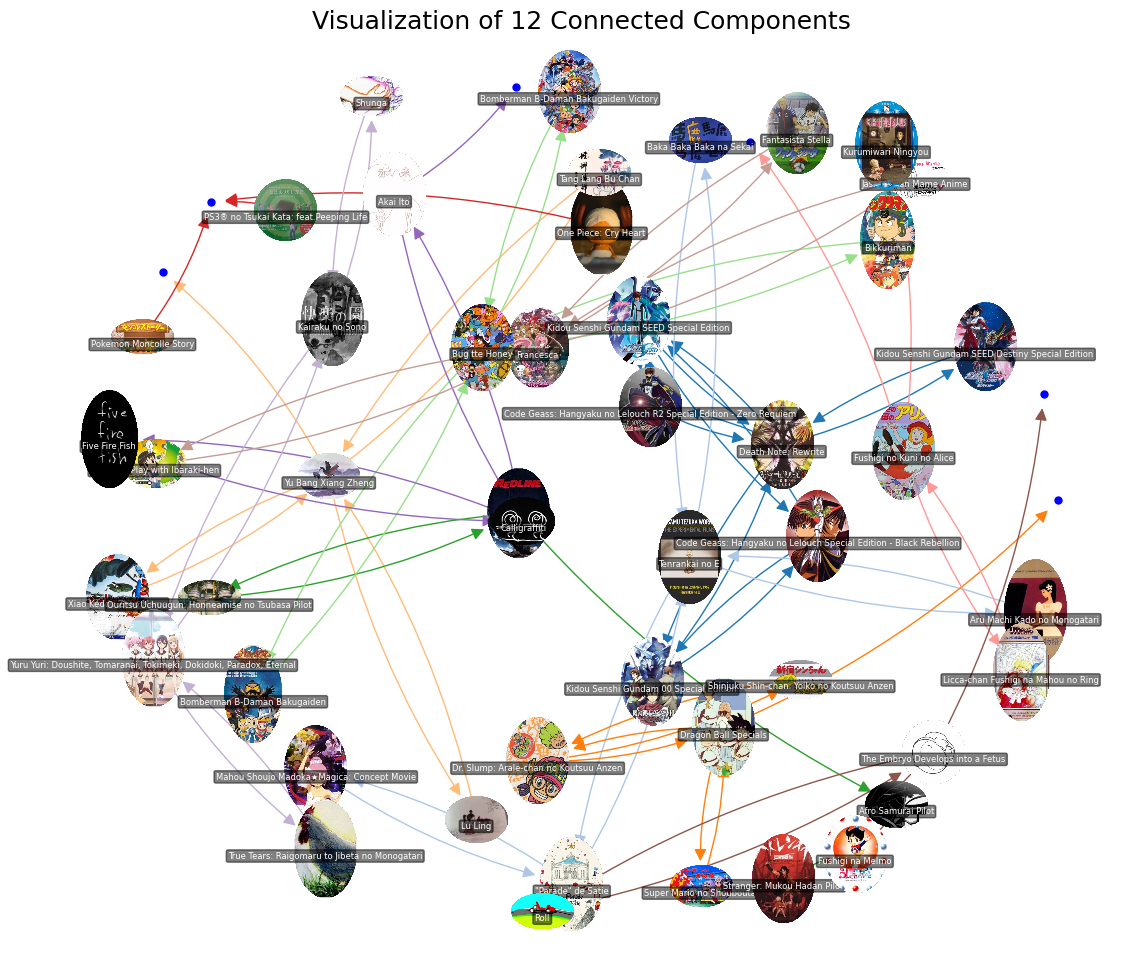

In [21]:
visualize_cc_images(animeGraph, image_folder = 'cropped_images', max_components=12, min_size=4, max_size=10, show_labels=True)

##### 2. __Most Connected Anime in a Genre__

In this section, I explore the idea of centrality in my network by creating a system to find the most connected anime for any particular genre.

These anime tend to have a high degree of popularity, and are often recommended by other animes across different genres. So for anyone who might want to explore a new genre of anime - these titles can be good starting points.

In [22]:
gen_id, gen_name = zip(*get_unique_id_name_pairs(anime.genres))
gen_counts = pd.DataFrame(count_id_name_pairs(anime.genres).items(), columns=['genre','count'])

In [23]:
gen_counts.sample(5)

,genre,count
20,Romance,1815
39,Iyashikei,165
24,Award Winning,223
54,Gourmet,118
27,Mecha,1046


In [24]:
gen_counts_sorted = gen_counts.sort_values(by='count', ascending=False).reset_index(drop=True)

In [25]:
gen_counts_sorted.head(5)

,genre,count
0,Comedy,5219
1,Action,4357
2,Fantasy,3413
3,Adventure,2949
4,Sci-Fi,2554


In [26]:
genre_dict = get_id_genre_dict(anime)
nx.set_node_attributes(animeGraph, genre_dict, 'genres')

In [27]:
# filter function for genre
def is_genre(node, genre):
    if 'genres' in animeGraph.nodes[node]:
        return genre in animeGraph.nodes[node]['genres']
    return False

# find the most connected anime
def find_most_connected_anime(graph):
    degrees = dict(graph.in_degree())
    most_connected_id = max(degrees, key=degrees.get)
    # Get the title of the most connected anime
    most_connected_title = graph.nodes[most_connected_id]['title']
    return most_connected_title, degrees[most_connected_id], most_connected_id

In [28]:
# return the most connected anime for a given genre and graph
def find_most_connected_anime_by_genre(graph, genre):
    genre_view = nx.subgraph_view(graph, filter_node=lambda n: is_genre(n, genre))

    genre_title, genre_deg, genre_id = find_most_connected_anime(genre_view)
    return genre_title, genre_deg, genre_id

In [29]:
# adventure_view = nx.subgraph_view(animeGraph, filter_node=lambda n: is_genre(n, 'Adventure'))
# adv_id, adv_deg = find_most_connected_anime(adventure_view)
genre = 'Racing'
adv_title, adv_deg, adv_id = find_most_connected_anime_by_genre(animeGraph, genre)

print(f"most connected anime in {genre} genre:", adv_title)
print("in degree:", adv_deg)

most connected anime in Racing genre: Initial D First Stage
in degree: 13


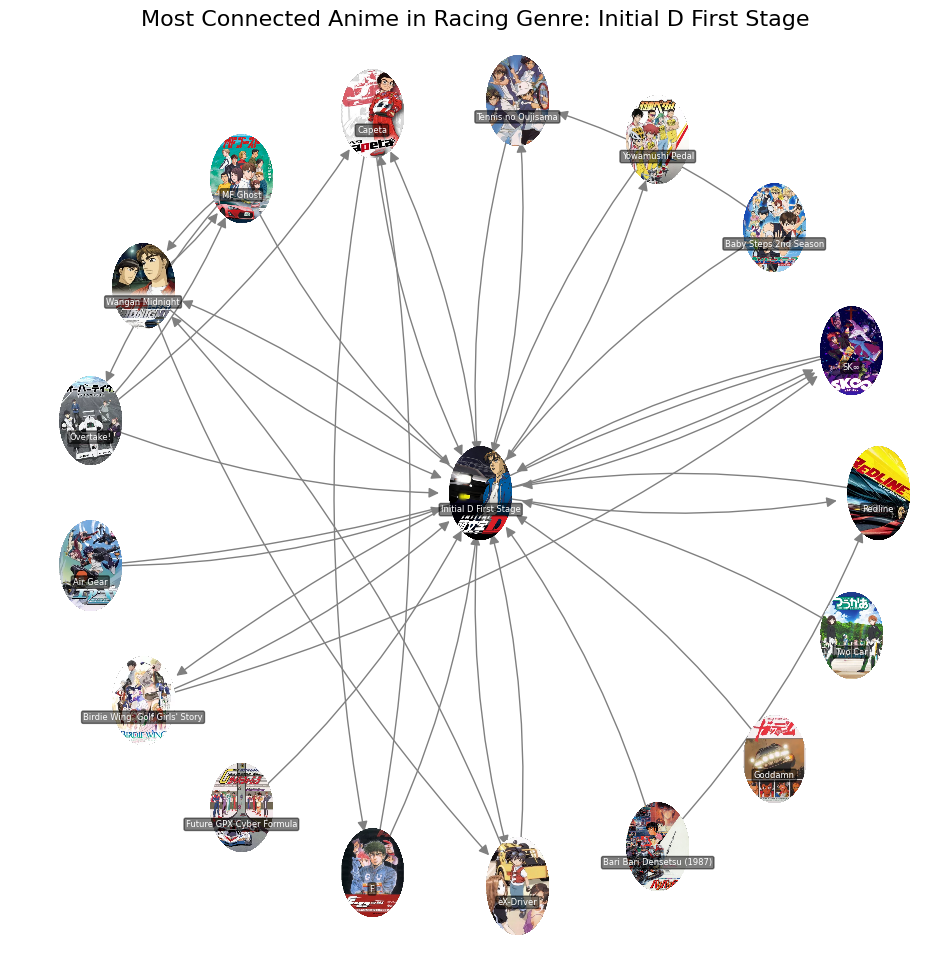

In [30]:
draw_star_network_with_images(
    animeGraph, adv_id, anime, genre_dict,
    image_folder="cropped_images",
    zoom=0.2,
    title=f"Most Connected Anime in {genre} Genre: {adv_title}",
    show_labels=True
)

most connected anime in Comedy genre: Gintama
in degree: 90
most connected anime in Action genre: Shinseiki Evangelion
in degree: 100
most connected anime in Fantasy genre: Sword Art Online
in degree: 59
most connected anime in Adventure genre: Sword Art Online
in degree: 45
most connected anime in Sci-Fi genre: Shinseiki Evangelion
in degree: 94


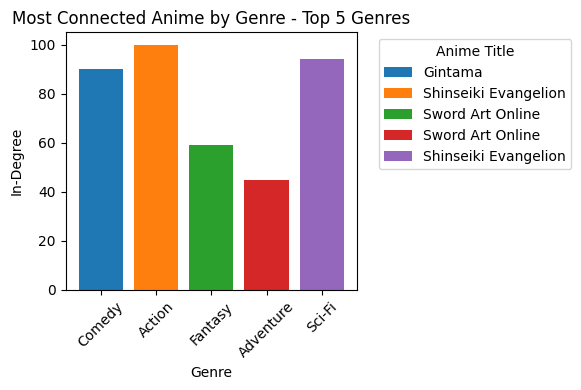

In [31]:
top_genres = gen_counts_sorted.head(5)['genre'].tolist()

# print the most connected anime for the top 5 genres
for genre in top_genres:
    adv_title, adv_deg, adv_id = find_most_connected_anime_by_genre(animeGraph, genre)
    print(f"most connected anime in {genre} genre:", adv_title)
    print("in degree:", adv_deg)

# make a bar graph of the most connected anime in the top 5 genres
def plot_most_connected_anime_by_genre(graph, genres):
    fig, ax = plt.subplots(figsize=(6, 4))

    for genre in genres:
        title, deg, anime_id = find_most_connected_anime_by_genre(graph, genre)
        ax.bar(genre, deg, label=title)

    ax.set_xlabel('Genre')
    ax.set_ylabel('In-Degree')
    ax.set_title('Most Connected Anime by Genre - Top 5 Genres')
    ax.legend(title='Anime Title', bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

plot_most_connected_anime_by_genre(animeGraph, top_genres)

##### 3. __Shortest Path Between 2 Anime, if it exists__

An interaction that allows involves picking 2 animes in the network and finding the shortest path between them if it exists.

For an improved user experience, the system was built to allow for direct title input with typo protection. As long as the titles inputted form a close enough match with one from the dataset, it will automatically determine the node ids to use.

In [32]:
from rapidfuzz.distance import Levenshtein
from rapidfuzz import fuzz

# Computes a similarity score between two strings based on a combination
# between jaro-winkler and levenshtein distance.
def combined_similarity(str1: str, str2: str) -> float:
    str1 = str(str1).lower()
    str2 = str(str2).lower()
    # Levenshtein similarity (normalized)
    lev_distance = Levenshtein.distance(str1, str2)
    max_len = max(len(str1), len(str2))
    if max_len == 0:
        levenshtein_sim = 1.0  # Both strings are empty
    else:
        levenshtein_sim = 1 - (lev_distance / max_len)
    
    # Jaro-Winkler similarity
    jaro_winkler_sim = fuzz.WRatio(str1, str2) / 100.0  # WRatio gives 0-100
    
    # Combine them - using 60% jaro-winkler and 40% levenshtein to prefer initial similarity
    combined_score = (0.4 * levenshtein_sim) + (0.6 * jaro_winkler_sim)
    
    return combined_score

In [33]:
# function to find the most similar anime title given a string
def find_most_similar_anime_title(input_title, anime_titles):
    max_similarity = 0
    most_similar_title = None

    for title in anime_titles:
        similarity = combined_similarity(input_title, title)
        if similarity > max_similarity:
            max_similarity = similarity
            most_similar_title = title

    return most_similar_title, max_similarity

# same as above but for lists of lists of titles
def find_most_similar_anime_title_all(input_title, anime_titles_all):
    max_similarity = 0
    most_similar_title = None

    for titles in anime_titles_all:
        for candidate in titles:
            similarity = combined_similarity(input_title, candidate)
            if similarity > max_similarity:
                max_similarity = similarity
                most_similar_title = titles[0]  # Always return the main title

    return most_similar_title, max_similarity

In [34]:
# Takes two anime IDs and finds the shortest path between them if it exists
def find_shortest_path(graph, source, target):
    try:
        path = nx.shortest_path(graph, source=source, target=target)
        named_path = [get_anime_title(node) for node in path]
        print(f"Shortest path from {graph.nodes[source]['title']} to {graph.nodes[target]['title']}: {named_path}")
        print(f"Path length: {len(path) - 1}")
        return path
    except nx.NetworkXNoPath:
        print(f"No path exists between {source} and {target}.")
    except nx.NodeNotFound:
        return None

# Combines the similarity and pathfinding functions, takes 2 strings and finds the most similar anime titles, 
# then finds the shortest path between them
def find_path_between_titles(graph, title1, title2):
    most_similar_title1, _ = find_most_similar_anime_title_all(title1, anime_titles_all)
    most_similar_title2, _ = find_most_similar_anime_title_all(title2, anime_titles_all)

    if most_similar_title1 and most_similar_title2:
        id1 = anime[anime['title'] == most_similar_title1]['id'].values[0]
        id2 = anime[anime['title'] == most_similar_title2]['id'].values[0]

        print(f"Most similar title to '{title1}': {most_similar_title1}")
        print(f"Most similar title to '{title2}': {most_similar_title2}")

        return find_shortest_path(graph, id1, id2)
    else:
        print("Could not find similar titles.")
        return None

Shortest path from One Piece to Ajin: ['One Piece', 'Hunter x Hunter (2011)', 'JoJo no Kimyou na Bouken Part 3: Stardust Crusaders', 'Ajin']
Path length: 3


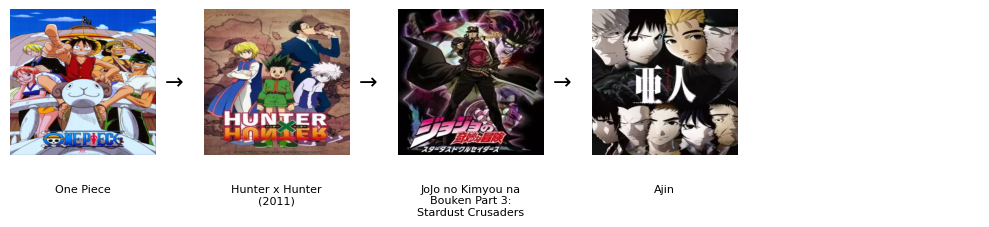

In [35]:
visualize_anime_path(find_shortest_path(animeGraph, 21, 31580), zoom=0.75)

Most similar title to 'attack on titan': Shingeki no Kyojin
Most similar title to 'naruruto': Naruto
Shortest path from Shingeki no Kyojin to Naruto: ['Shingeki no Kyojin', 'Owari no Seraph', 'Ao no Exorcist', 'Naruto']
Path length: 3


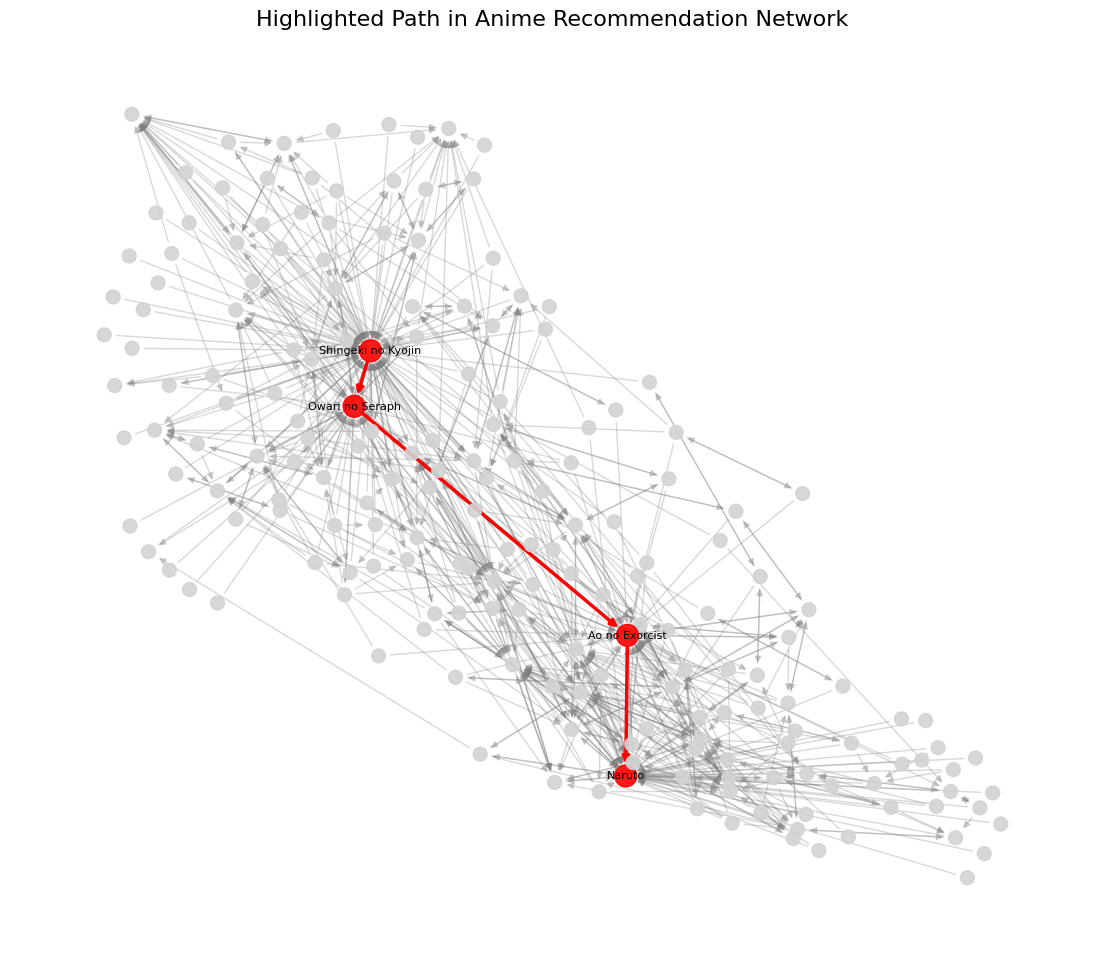

In [36]:
visualize_path_in_network(animeGraph,find_path_between_titles(animeGraph, 'attack on titan', 'naruruto'), zoom = 0.5)

##### 3.1 __The One Piece Number__

An extension of the path analysis, and inspired by the kevin bacon number.

We look at the largest connected component and find the median path length as well as the maximum path length to reach from and to 'One Piece' one of the most popular and influential anime in the past few decades.

In [44]:
# Find all weakly connected components
components = list(nx.weakly_connected_components(animeGraph))

# Find the largest one
largest_component = max(components, key=len)

# Create subgraph
LCC = animeGraph.subgraph(largest_component).copy()

In [51]:
one_piece_id = 21  # One Piece

# Compute all shortest paths from One Piece
lengths = nx.single_source_shortest_path_length(LCC, source=one_piece_id)

# Exclude self
path_lengths = {node: dist for node, dist in lengths.items() if node != one_piece_id}

# Summary stats
values = list(path_lengths.values())
print(f"Median path length from One Piece: {statistics.median(values)}")
print(f"Max path length from One Piece: {max(values)}")
print(f"Reachable anime: {len(values)} / {LCC.number_of_nodes() - 1}")

# Find farthest node(s)
max_dist = max(values)
farthest_nodes = [node for node, dist in path_lengths.items() if dist == max_dist]

print(f"\nFarthest anime from One Piece (distance = {max_dist}):")
for node in farthest_nodes:
    print(f"- {get_anime_title(node)} (ID: {node})")

Median path length from One Piece: 6
Max path length from One Piece: 14
Reachable anime: 5325 / 6989

Farthest anime from One Piece (distance = 14):
- Naruto: Shippuuden Movie 4 - The Lost Tower (ID: 8246)
- Lupin III: Prison of the Past (ID: 40578)
- Zan Sayonara Zetsubou Sensei (ID: 6377)


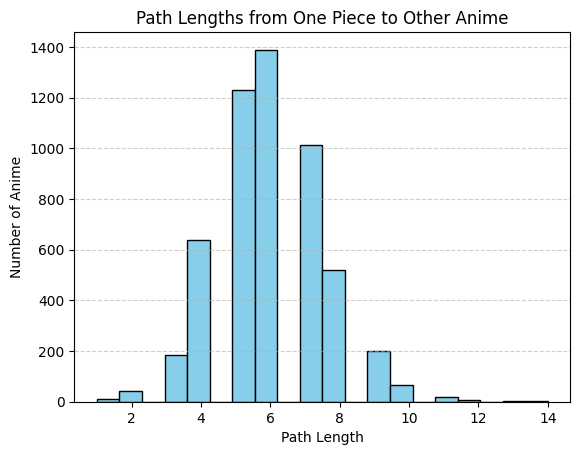

In [52]:
# Plot histogram of the path length distributions
plt.hist(values, bins=20, color='skyblue', edgecolor='black')
plt.title("Path Lengths from One Piece to Other Anime")
plt.xlabel("Path Length")
plt.ylabel("Number of Anime")
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.show()

In [54]:
one_piece_id = 21  # One Piece

# Reverse the graph to trace paths *into* One Piece
reversed_LCC = LCC.reverse(copy=True)

# Compute shortest paths *to* One Piece
lengths_to_op = nx.single_source_shortest_path_length(reversed_LCC, source=one_piece_id)

# Exclude One Piece itself
path_lengths = {node: dist for node, dist in lengths_to_op.items() if node != one_piece_id}

# Summary stats
values = list(path_lengths.values())
print(f"Median path length to One Piece: {statistics.median(values)}")
print(f"Max path length to One Piece: {max(values)}")
print(f"Number of anime that lead to One Piece: {len(values)} / {LCC.number_of_nodes() - 1}")

# Find farthest node(s)
max_dist = max(values)
farthest_nodes = [node for node, dist in path_lengths.items() if dist == max_dist]

print(f"\nFarthest anime *leading to* One Piece (distance = {max_dist}):")
for node in farthest_nodes:
    print(f"- {get_anime_title(node)} (ID: {node})")

Median path length to One Piece: 4
Max path length to One Piece: 9
Number of anime that lead to One Piece: 6579 / 6989

Farthest anime *leading to* One Piece (distance = 9):
- Shingeki no Kyotou (ID: 35122)
- Seiji no Rinrika (ID: 35366)
- Maria-sama ga Miteru 3rd Specials (ID: 2954)
- Kimi no Matsu Mirai (Basho) e (ID: 38678)


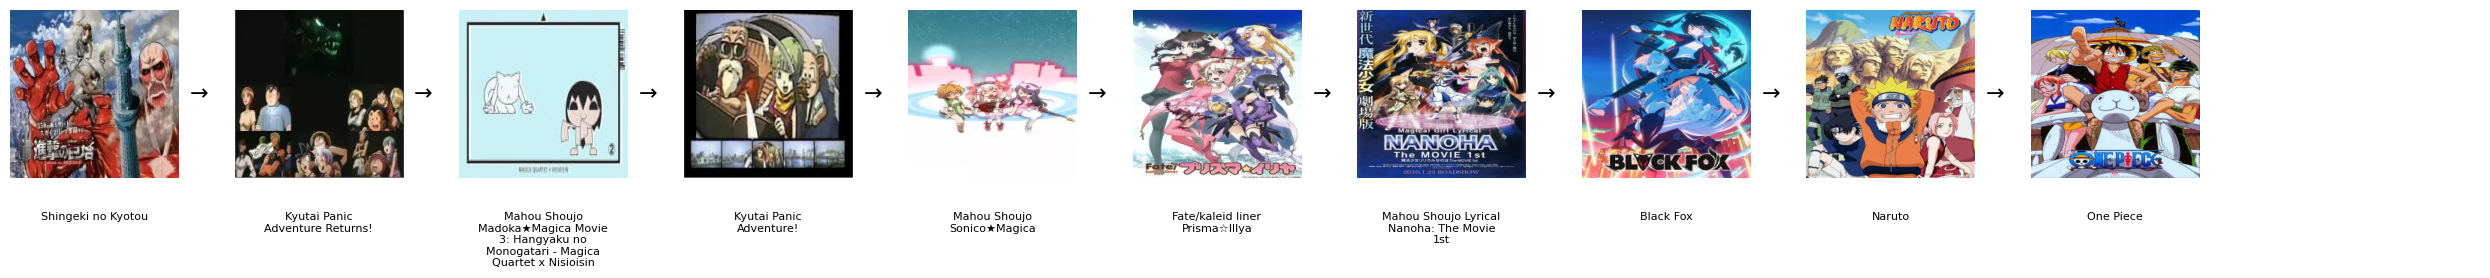

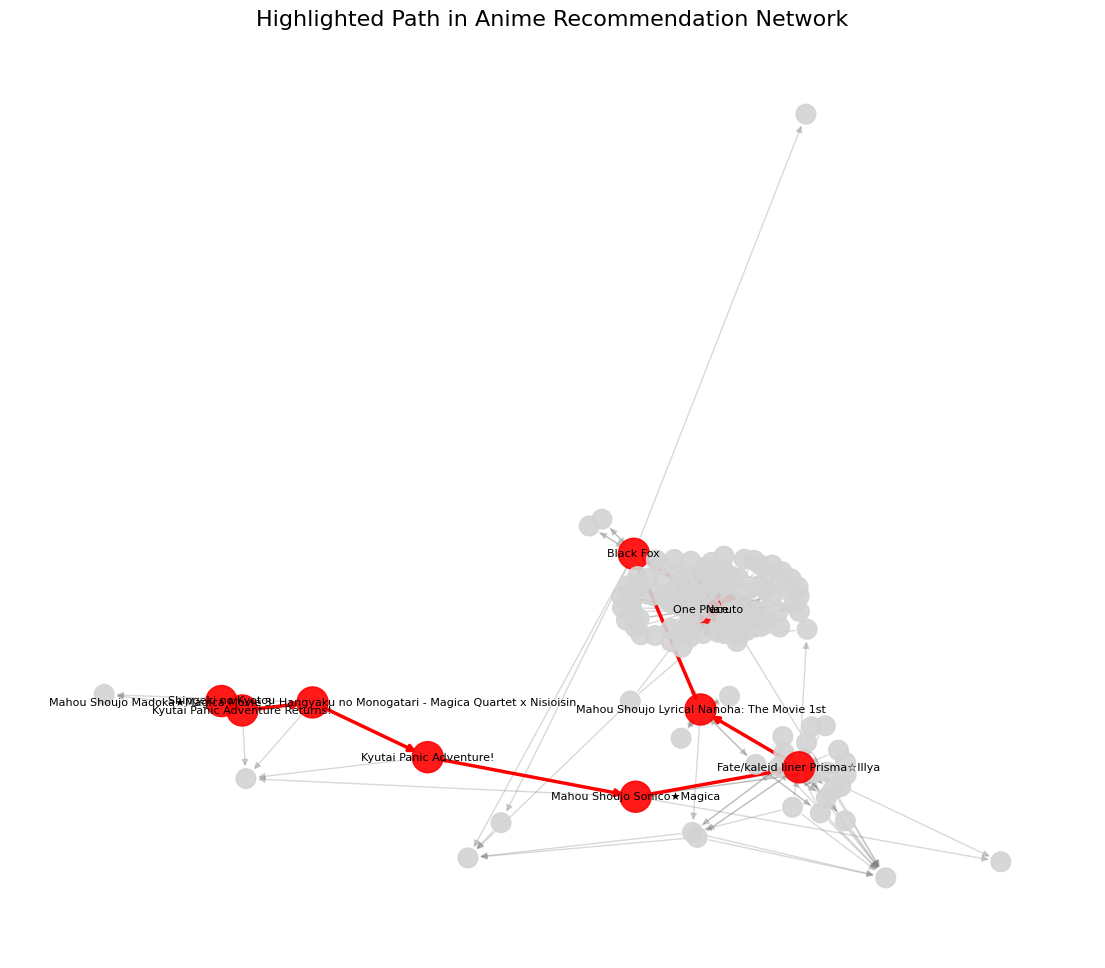

In [55]:
farthest_id = farthest_nodes[0]
path = nx.shortest_path(reversed_LCC, source=one_piece_id, target=farthest_id)
path = path[::-1]  # flip direction to go start → One Piece

visualize_anime_path(path, image_folder="images", zoom=0.75)
# or:
visualize_path_in_network(LCC, path_ids=path)

##### 4. __Get Anime Information when picking a Node__

A simple interaction that highlights that nodes in a network can hold a lot of information through their attributes.

In this case, I wrote a function that, when given a node ID for an anime, prints out the anime that are recommended as well as those anime that recommend it. Additionally, some other node attributes are highlighted as well.

On the MyAnimeList website, it is easy to see what recommendations are given after watching a certain anime, but not possible to see which anime lead to the one you just watched.

In [576]:
def get_anime_info(anime_id):
    '''
    get anime info, both from the graph and the anime dataframe
    and then print it out
    '''
    # find the degree of the node
    deg = animeGraph.in_degree(anime_id)
    # find the anime that recommend this one
    recommenders = list(animeGraph.predecessors(anime_id))
    # find the anime that this one recommends
    recommendeds = list(animeGraph.successors(anime_id))
    # get the title of the anime
    title = anime[anime['id'] == anime_id]['title'].values[0]

    #print the info
    print(f"Title: {title}")
    print(f"ID: {anime_id}")
    print(f"In Degree: {deg}")
    print(f"Recommenders: {recommenders}")
    print(f"Recommendeds: {recommendeds}")
    print(f"Genres: {animeGraph.nodes[anime_id]['genres']}")

In [577]:
get_anime_info(31580)

Title: Ajin
ID: 31580
In Degree: 20
Recommenders: [22535, 20899, 22319, 19775, 34542, 53770, 23279, 32086, 620, 27899, 36548, 35928, 12035, 38799, 2312, 38628, 37436, 39063, 34048, 19315]
Recommendeds: [22319, 22535, 1535, 34542, 226, 20899, 36548, 31240, 23283, 35120]
Genres: ['Action', 'Gore', 'Horror', 'Mystery', 'Seinen', 'Supernatural']


##### 5. __Centrality Analysis__ - Anime that serve as bridges to others

In this section, we look at the largest weakly connected component and run some centrality analysis on it. The reason the largest component is isolated is because it best represents anime as a whole. Additionally, the other connected components are too small to have this type of analysis done to them.

In [ ]:
# Compute betweenness only for the largest connected part
betweenness = nx.betweenness_centrality(LCC, normalized=True)

# Sort nodes
important_nodes = sorted(betweenness.items(), key=lambda x: x[1], reverse=True)

# Print top 10
for node_id, score in important_nodes[:10]:
    print(f"{get_anime_title(node_id)}: {score:.4f}")

![Alt text](betweenness.png)

#### __Bonus Objective 1: Traversal Game__

This section features an anime traversal game that puts together some of the ideas of connected components and network path finding into an interactive experience.

The premise is that two random anime that can be found on the same weakly connected component are selected and the player is then tasked to traverse the network through the neighbors of one to reach the other.

Playing the game and getting the optimal solution is surprisingly difficult, even though most nodes are linked by a path of at most 6-7 in length.

In [580]:
def find_random_distant_nodes(graph, min_path_length=2, max_attempts=1000):
    '''
    Find a random pair of nodes in the graph that are at least a certain distance apart.
    To avoid impossible scenarios we filter out any components that are too small.
    Then we probabilistically weigh the components based on their size.
    This will give larger components a higher chance of being selected. which is useful because
    most of the components are small.
    '''

    # find the weakly connected components of the graph
    components = list(nx.weakly_connected_components(graph))
    # filter out the components that are too small
    components = [c for c in components if len(c) > min_path_length]
    # if there are no components that are large enough, return None
    if len(components) == 0:
        return None, None
    
    # Probabilitistcally weigh the components based on their size
    # This will give larger components a higher chance of being selected
    sizes = [len(c) for c in components]
    total_size = sum(sizes)
    probabilities = [size / total_size for size in sizes]

    # begin loop to find the nodes
    for _ in range(max_attempts):
        # pick a random component weighted by size
        component = random.choices(components, weights=probabilities, k=1)[0]
        # pick a random node from the component
        node1 = random.choice(list(component))
        # pick a random node from the component that is not the same as node1
        node2 = random.choice(list(component - {node1}))

        # find the shortest path between the two nodes
        try:
            path_length = nx.shortest_path_length(graph, source=node1, target=node2)
            if path_length >= min_path_length:
                return node1, node2
        except nx.NetworkXNoPath:
            continue
        except nx.NodeNotFound:
            continue

    return None, None

In [581]:
def play_game(animeGraph, randomNode1, randomNode2):
    gameState = True
    stepsTaken = 0
    currentNode = randomNode1
    targetNode = randomNode2

    # Validate start and end nodes
    if get_anime_title(randomNode1) is None:
        print(f"Warning: Invalid randomNode1 ID: {randomNode1}")
        return
    if get_anime_title(randomNode2) is None:
        print(f"Warning: Invalid randomNode2 ID: {randomNode2}")
        return

    print("\nType 'EXIT' at any time to give up and reveal the shortest path!\n")

    while gameState:
        print("\nYou are at anime:", get_anime_title(currentNode))
        print("Target anime:", get_anime_title(targetNode))
        
        # List neighbors
        neighbors = list(animeGraph.neighbors(currentNode))
        neighbor_titles = [(n, get_anime_title(n)) for n in neighbors]
        valid_neighbors = [(n, title) for n, title in neighbor_titles if title is not None]

        if not valid_neighbors:
            print("No available moves! Game over.")
            break

        # Show options
        print("You can go to the following anime:")
        for idx, (node_id, title) in enumerate(valid_neighbors):
            print(f"{chr(65 + idx)}: {title}")

        # Get input
        choice = input("Enter the letter of the anime you want to go to (or type 'EXIT' to give up): ").strip().upper()

        if choice == "EXIT":
            print("\nYou chose to exit the game.")
            print(f"The shortest path from {get_anime_title(randomNode1)} to {get_anime_title(targetNode)} is:")
            find_shortest_path(animeGraph, randomNode1, targetNode)
            break

        # Normal move handling
        if choice.isalpha() and 0 <= ord(choice) - 65 < len(valid_neighbors):
            target = valid_neighbors[ord(choice) - 65][0]
            if target in neighbors:
                currentNode = target
                stepsTaken += 1
                print(f"You moved to: {get_anime_title(currentNode)}")
                if currentNode == targetNode:
                    print(f"\n🎉 Congratulations! You reached the target anime: {get_anime_title(targetNode)}!")
                    print(f"You took {stepsTaken} steps.")
                    print("\n(Here's the optimal path for comparison!)")
                    find_shortest_path(animeGraph, randomNode1, targetNode)
                    gameState = False
            else:
                print("Invalid move. Please try again.")
        else:
            print("Invalid input. Please select a valid letter option.")


In [582]:
def play_game_images(animeGraph, randomNode1, randomNode2, image_folder="images"):
    gameState = True
    stepsTaken = 0
    currentNode = randomNode1
    targetNode = randomNode2

    if get_anime_title(randomNode1) is None or get_anime_title(randomNode2) is None:
        print("Invalid start or target node.")
        return

    while gameState:
        clear_output(wait=True)
        print("\n🎮 Welcome to the Anime Traversal Game!")
        print("Type 'EXIT' at any time to give up and reveal the shortest path.\n")
        print(f"\n📍 You are at: {get_anime_title(currentNode)}")
        print(f"🎯 Target: {get_anime_title(targetNode)}")

        # Show current and target images
        fig, axs = plt.subplots(1, 2, figsize=(4, 3))
        for ax, node_id, label in zip(axs, [currentNode, targetNode], ['Current', 'Target']):
            img_path = os.path.join(image_folder, f"{node_id}.jpg")
            if os.path.exists(img_path):
                img = Image.open(img_path)
                ax.imshow(img)
                ax.axis('off')
                title = get_anime_title(node_id)
                wrapped_title = fill(title, width=20)
                ax.set_title(f"{label}\n{wrapped_title}", fontsize=8)
        plt.tight_layout()
        plt.show()

        # List valid neighbors
        neighbors = list(animeGraph.neighbors(currentNode))
        neighbor_titles = [(n, get_anime_title(n)) for n in neighbors]
        valid_neighbors = [(n, title) for n, title in neighbor_titles if title is not None]

        if not valid_neighbors:
            print("❌ No available moves. Game over.")
            break

        print("\nYou can go to the following anime:")
        fig, axs = plt.subplots(1, len(valid_neighbors), figsize=(2.5 * len(valid_neighbors), 3))
        if len(valid_neighbors) == 1:
            axs = [axs]

        # show images for neighbors
        for idx, (node_id, title) in enumerate(valid_neighbors):
            label = chr(65 + idx)
            print(f"{label}: {title}")
            img_path = os.path.join(image_folder, f"{node_id}.jpg")
            if os.path.exists(img_path):
                axs[idx].imshow(Image.open(img_path))
            axs[idx].axis('off')
            wrapped_title = fill(title, width=20)
            axs[idx].set_title(f"{label}\n{wrapped_title}", fontsize=8)
        plt.tight_layout()
        plt.show()

        # Get input
        choice = input("Enter the letter of the anime you want to go to (or type 'EXIT'): ").strip().upper()

        if not choice:
            continue

        if choice == "EXIT":
            print("\n📤 You chose to exit. Here's the shortest path:")
            find_shortest_path(animeGraph, randomNode1, targetNode)
            break

        if choice.isalpha() and 0 <= ord(choice) - 65 < len(valid_neighbors):
            idx = ord(choice) - 65
            currentNode = valid_neighbors[idx][0]
            stepsTaken += 1
            ...
        else:
            print("⚠️ Invalid input. Please select a valid letter.")
        if 0 <= idx < len(valid_neighbors):
            currentNode = valid_neighbors[idx][0]
            stepsTaken += 1
            print(f"✅ Moved to: {get_anime_title(currentNode)}")

            if currentNode == targetNode:
                print(f"\n🎉 You reached the target anime: {get_anime_title(targetNode)} in {stepsTaken} steps!")
                print("\n(Here’s the optimal path for comparison:)")
                find_shortest_path(animeGraph, randomNode1, targetNode)
                gameState = False
        else:
            print("⚠️ Invalid input. Please select a valid letter.")


🎮 Welcome to the Anime Traversal Game!
Type 'EXIT' at any time to give up and reveal the shortest path.


📍 You are at: Toradora!
🎯 Target: Pokemon Advanced Generation


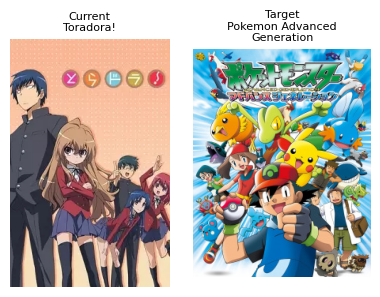


You can go to the following anime:
A: Zero no Tsukaima
B: Lovely★Complex
C: Golden Time
D: Sakura-sou no Pet na Kanojo
E: Clannad
F: Chuunibyou demo Koi ga Shitai!
G: Nisekoi
H: Shakugan no Shana
I: Horimiya
J: Tonari no Kaibutsu-kun


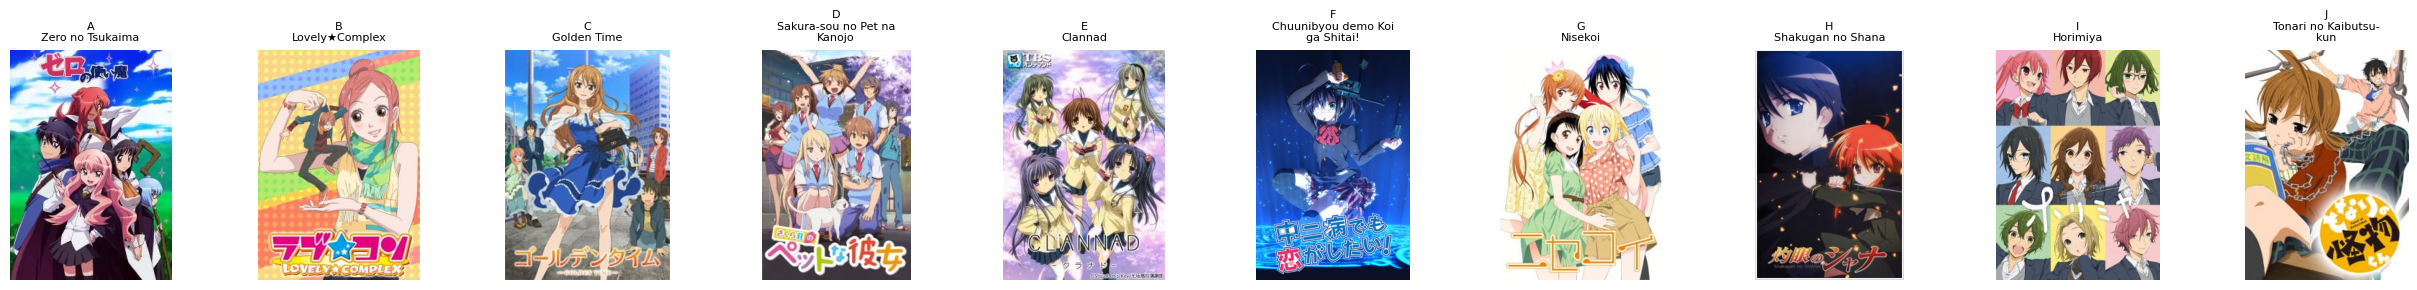


📤 You chose to exit. Here's the shortest path:
Shortest path from Mizuiro (2003) to Pokemon Advanced Generation: ['Mizuiro (2003)', 'Lamune', 'Tonagura!', 'Sora no Manimani', 'Ebiten: Kouritsu Ebisugawa Koukou Tenmonbu', 'Saint Seiya', 'Metal Fight Beyblade', 'Yu☆Gi☆Oh! Duel Monsters GX', 'Pokemon Advanced Generation']
Path length: 8


In [583]:
# Plays the Game
randomNode1, randomNode2 = find_random_distant_nodes(animeGraph, min_path_length=2)
play_game_images(animeGraph, randomNode1, randomNode2)

#### __Bonus Objective 2: Anime Recommendation__

This bonus objective combines ideas of node attributes and network connection strength (weighting) to create a simple anime recommendation system that doesnt just recommend the strongest (most connected anime) but also takes into account other node attributes such as genre composition and frequency of past recommendations.

In [584]:
# Recommendation cache to track how often an anime is recommended
recommendation_count = defaultdict(int)

#### __Recommendation Weight Methodology__
- Score = Sum(Recommendation Counts) * Genre Difference Factor
- __Recommendation Count__: number of recommendations given in the network, the primary influencer of the score
- __Score__: how strongly the inputs recommend it, higher score is better
    * It is computed as the sums of the scores of the anime that are provided
    * Score is based on the recommendation count as well as influenced by bigger differences in genre
    * Ties are broken by using the cache, biased towards less recommended
- __overlap_threshold__: the percentage of genre overlap between an input anime and recommended anime
- __genre_boost__: 1+genre_boost multiplier is applied to anime scores that hit the overlap threshold
- Overall we prefer candidates with stronger links, but between those with the same strength, we prefer the less recommended one
- Additionally recommendations with slightly less recommendation count but with bigger genre differences might be recommended more

In [585]:
def recommend_anime(user_inputs, animeGraph, anime_titles_all, num_recommendations=3,
                    genre_boost=0.2, overlap_threshold=0.5):
    """
    Recommend anime using graph structure + genre diversity bonus.
    
    genres are pulled directly from animeGraph node attributes.
    """
    matched_anime_ids = []

    # 1. Match user input to anime IDs using title similarity
    for input_title in user_inputs:
        matched_title, sim = find_most_similar_anime_title_all(input_title, anime_titles_all)
        print(f"Matched “{input_title}” ➜ “{matched_title}” (sim {sim:.2f})")
        if matched_title is None:
            continue
        row = anime.loc[anime["title"] == matched_title]
        if not row.empty:
            matched_anime_ids.append(int(row.iloc[0]["id"]))

    if not matched_anime_ids:
        print("No valid titles found — cannot recommend.")
        return []

    # 2. Collect all input genres from node attributes
    input_genres = set()
    for anime_id in matched_anime_ids:
        input_genres.update(animeGraph.nodes[anime_id].get('genres', []))

    # 3. Gather neighbor candidates and raw scores
    raw_scores = defaultdict(int)

    for src in matched_anime_ids:
        if not animeGraph.has_node(src):
            continue
        for tgt in animeGraph.successors(src):
            w = animeGraph[src][tgt].get("weight", 1)
            raw_scores[tgt] += w

    for src in matched_anime_ids:
        raw_scores.pop(src, None)  # exclude originals

    if not raw_scores:
        print("No neighbors found for selected anime.")
        return []

    # 4. Adjust scores based on genre differences
    final_scores = {}

    for candidate_id, base_score in raw_scores.items():
        candidate_genres = set(animeGraph.nodes[candidate_id].get('genres', []))
        
        intersection = input_genres & candidate_genres
        union = input_genres | candidate_genres
        overlap = len(intersection) / len(union) if union else 0

        if overlap < overlap_threshold:
            bonus = base_score * genre_boost
            adjusted_score = base_score + bonus
        else:
            adjusted_score = base_score

        final_scores[candidate_id] = adjusted_score

    # 5. Rank candidates by final score + novelty
    ranked = sorted(
        final_scores.items(),
        key=lambda kv: (-kv[1], recommendation_count[kv[0]])
    )

    # 6. Pick top-k and update recommendation count
    selected = []
    for cand_id, _ in ranked:
        if len(selected) == num_recommendations:
            break
        title = get_anime_title(cand_id)
        if title:
            selected.append((cand_id, title))
            recommendation_count[cand_id] += 1

    # 7. Output
    print("\nRecommended Anime:")
    for _, title in selected:
        print(f"• {title}")

    return selected


In [586]:
# Prompt for up to 3 favorite anime titles
def get_user_favorite_anime():
    user_inputs = []
    print("Please enter 1 to 3 of your favorite anime titles!")
    for i in range(3):
        user_input = input(f"Enter anime title #{i+1} (or press Enter to skip): ").strip()
        if user_input == "":
            break  # Allow early stop if they only want to input 1-2
        user_inputs.append(user_input)
    print(f"You entered: {user_inputs}")
    return user_inputs

In [587]:
# Example usage, recommend 5 anime based on user input
user_favorites = get_user_favorite_anime()
if user_favorites:
    recommend_anime(user_favorites, animeGraph, anime_titles_all, num_recommendations=5)
else:
    print("No anime titles entered. Exiting recommendation system.")

Please enter 1 to 3 of your favorite anime titles!
You entered: ['natutor', 'attack on titan', 'one piec']
Matched “natutor” ➜ “Natsu e no Tunnel, Sayonara no Deguchi” (sim 0.78)
Matched “attack on titan” ➜ “Shingeki no Kyojin” (sim 1.00)
Matched “one piec” ➜ “One Piece” (sim 0.92)

Recommended Anime:
• Hoshi no Koe
• Boku ga Aishita Subete no Kimi e
• Uchiage Hanabi, Shita kara Miru ka? Yoko kara Miru ka?
• Byousoku 5 Centimeter
• Koutetsujou no Kabaneri
